In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

In [3]:
# 1. UPLOAD AND PREPARE DATA
print(" Please upload 'Chocolate Sales.csv':")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

 Please upload 'Chocolate Sales.csv':


Saving Dataset Sales.csv to Dataset Sales.csv


In [4]:
# Load and DOUBLE the dataset
df_raw = pd.read_csv(filename)
df = pd.concat([df_raw, df_raw], ignore_index=True)

In [5]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [6]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
2183,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
2184,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
2185,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
2186,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384
2187,Karlen McCaffrey,India,70% Dark Bites,23-May-22,"$5,075",344


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   2188 non-null   object
 1   Country        2188 non-null   object
 2   Product        2188 non-null   object
 3   Date           2188 non-null   object
 4   Amount         2188 non-null   object
 5   Boxes Shipped  2188 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 102.7+ KB


In [8]:
# Data Cleaning
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
df['Month'] = df['Date'].dt.month
df['DayNum'] = df['Date'].dt.dayofweek # 0=Monday, 6=Sunday
df['IsWeekend'] = df['DayNum'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

sns.set(style="white")

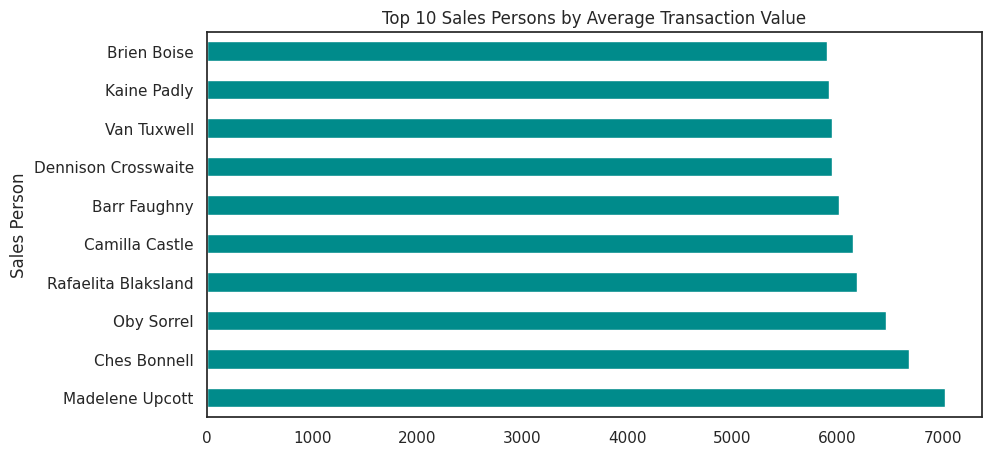

In [9]:
plt.figure(figsize=(10, 5))
df.groupby('Sales Person')['Amount'].mean().nlargest(10).plot(kind='barh', color='darkcyan')
plt.title('Top 10 Sales Persons by Average Transaction Value')
plt.show()

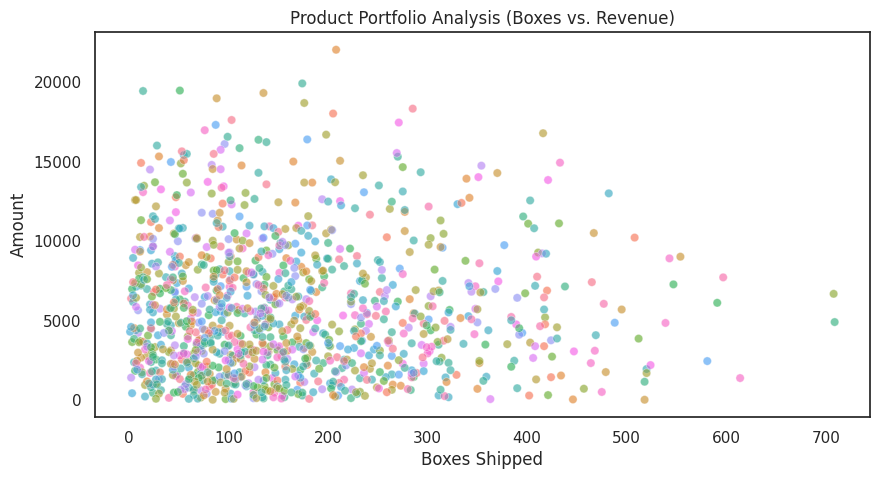

In [10]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Boxes Shipped', y='Amount', hue='Product', legend=False, alpha=0.4)
plt.title('Product Portfolio Analysis (Boxes vs. Revenue)')
plt.show()

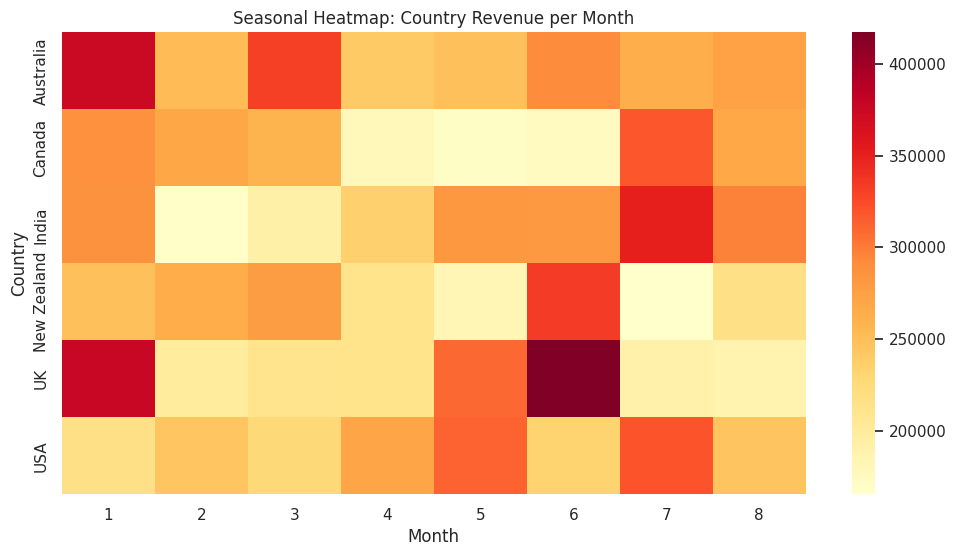

In [11]:
plt.figure(figsize=(12, 6))
heat_data = df.pivot_table(index='Country', columns='Month', values='Amount', aggfunc='sum')
sns.heatmap(heat_data, cmap='YlOrRd', annot=False)
plt.title('Seasonal Heatmap: Country Revenue per Month')
plt.show()

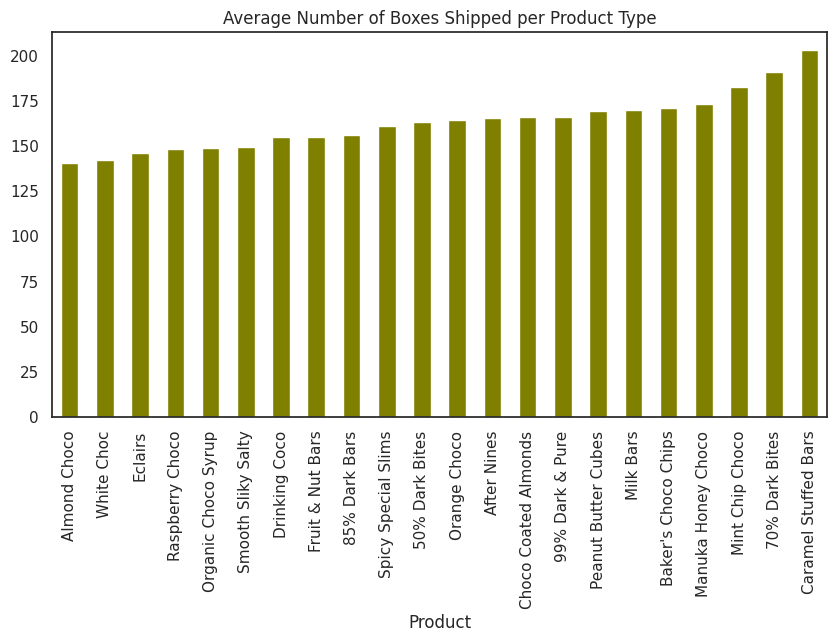

In [12]:
plt.figure(figsize=(10, 5))
df.groupby('Product')['Boxes Shipped'].mean().sort_values().plot(kind='bar', color='olive')
plt.title('Average Number of Boxes Shipped per Product Type')
plt.show()

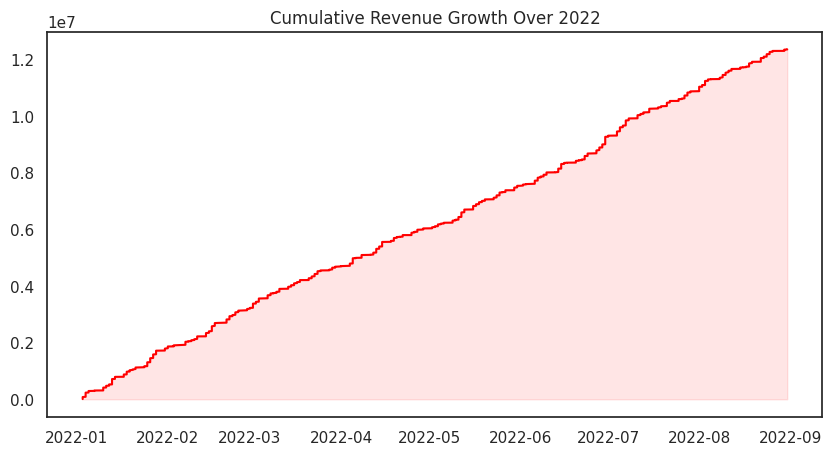

In [13]:
plt.figure(figsize=(10, 5))
df_sorted = df.sort_values('Date')
df_sorted['Cumulative_Sales'] = df_sorted['Amount'].cumsum()
plt.plot(df_sorted['Date'], df_sorted['Cumulative_Sales'], color='red')
plt.title('Cumulative Revenue Growth Over 2022')
plt.fill_between(df_sorted['Date'], df_sorted['Cumulative_Sales'], color='red', alpha=0.1)
plt.show()

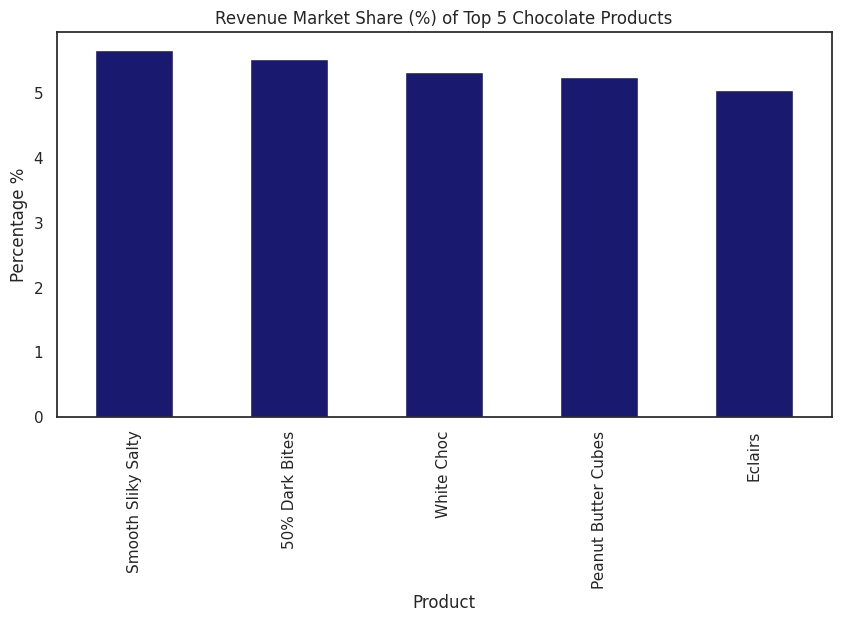

In [14]:
plt.figure(figsize=(10, 5))
top_5 = df.groupby('Product')['Amount'].sum().nlargest(5)
(top_5 / df['Amount'].sum() * 100).plot(kind='bar', color='midnightblue')
plt.title('Revenue Market Share (%) of Top 5 Chocolate Products')
plt.ylabel('Percentage %')
plt.show()

In [15]:
# DATA CLEANING & PREPROCESSING
# Safety check for 'Amount' formatting to prevent AttributeError
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].astype(str).str.replace('$', '').str.replace(',', '')
    df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
    df = df.dropna(subset=['Amount'])

# Date Features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df = df.dropna(subset=['Date'])

# Encoding categorical variables
le = LabelEncoder()
for col in ['Sales Person', 'Country', 'Product']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

In [16]:
# FEATURE SELECTION
features = ['Sales Person', 'Country', 'Product', 'Boxes Shipped', 'Month', 'Quarter']
X = df[features]
y = df['Amount']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Standard practice for ensemble models, though they are less sensitive than KNN/SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# MODEL 1: RANDOM FOREST REGRESSOR
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

#  MODEL 2: GRADIENT BOOSTING REGRESSOR
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)

In [18]:
# PERFORMANCE CALCULATION
results = []
for name, pred in [("Random Forest", rf_pred), ("Gradient Boosting", gb_pred)]:
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2
    })
    print(f"--- {name} Results ---")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

results_df = pd.DataFrame(results)

--- Random Forest Results ---
Mean Squared Error: 6537115.68
Mean Absolute Error: 1786.09
R2 Score: 0.5986

--- Gradient Boosting Results ---
Mean Squared Error: 14980526.90
Mean Absolute Error: 3057.92
R2 Score: 0.0801



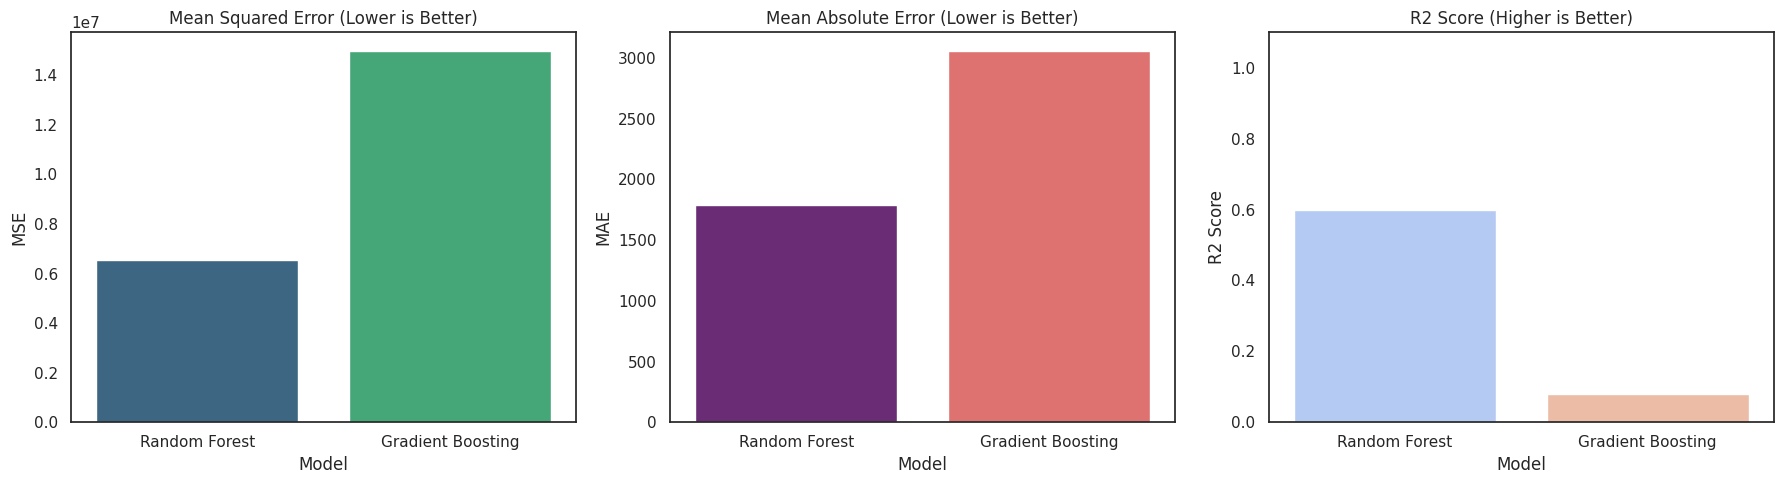

In [19]:
# VISUALIZATION COMPARISON FOR ALL VALUES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MSE Comparison
sns.barplot(x='Model', y='MSE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Squared Error (Lower is Better)')

# MAE Comparison
sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Absolute Error (Lower is Better)')

# R2 Comparison
sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[2], palette='coolwarm')
axes[2].set_title('R2 Score (Higher is Better)')
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()